# Análisis Exploratorio - Superstore Sales

## Objetivo
El objetivo de este proyecto es analizar las ventas y ganancias de un 
Superstore de retail en Estados Unidos durante el período 2014-2017.
A través de este análisis se busca identificar patrones de negocio,
entender qué categorías y regiones son más rentables, y detectar 
problemas como el impacto negativo de los descuentos excesivos.

## Dataset
- **Fuente:** Kaggle - Superstore Sales Dataset
- **Filas:** 9,993 | **Columnas:** 20
- **Período:** Enero 2014 - Diciembre 2017
- **Cobertura:** Retail en Estados Unidos con datos de órdenes,
  clientes, productos, ventas, descuentos y ganancias

## Preguntas de negocio
1. ¿Qué categoría y subcategoría genera más ventas y ganancia?
2. ¿Cómo han evolucionado las ventas a lo largo del tiempo?
3. ¿Qué regiones son las más rentables?
4. ¿Cómo afectan los descuentos a la ganancia?
5. ¿Qué segmento de clientes es el más val

In [9]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.io import load_csv
from src.cleaning import clean
from src.features import build_features
from src.utils import resumen

# Se carga el dataset usando la función modular de src/
df = load_csv()
df = clean(df)
df = build_features(df)
resumen(df)


Dataset cargado: 9994 filas, 21 columnas
Datos limpios: 9994 filas, 20 columnas
Features creadas: Profit Margin, Order Month, Order Year, Days to Ship
Filas: 9994
Columnas: 24
Nulos: 0
Duplicados: 1


## 1. ¿Qué categoría genera más ventas y ganancia?

Technology lidera tanto en ventas (~$840K) como en ganancia (~$145K), 
lo que la convierte en la categoría más estratégica del negocio.

Furniture genera un volumen de ventas similar a Office Supplies (~$740K) 
pero su ganancia es casi nula (~$18K). Esto se explica porque Furniture 
es la categoría con más descuentos aplicados, lo que erosiona 
completamente el margen de beneficio.

Office Supplies tiene ventas más bajas pero una ganancia sólida (~$122K), 
lo que indica que es una categoría eficiente con buenos márgenes.

**Conclusión:** No toda venta alta implica buena rentabilidad. 
Furniture es un ejemplo claro de cómo los descuentos excesivos 
pueden convertir una categoría popular en una poco rentable.

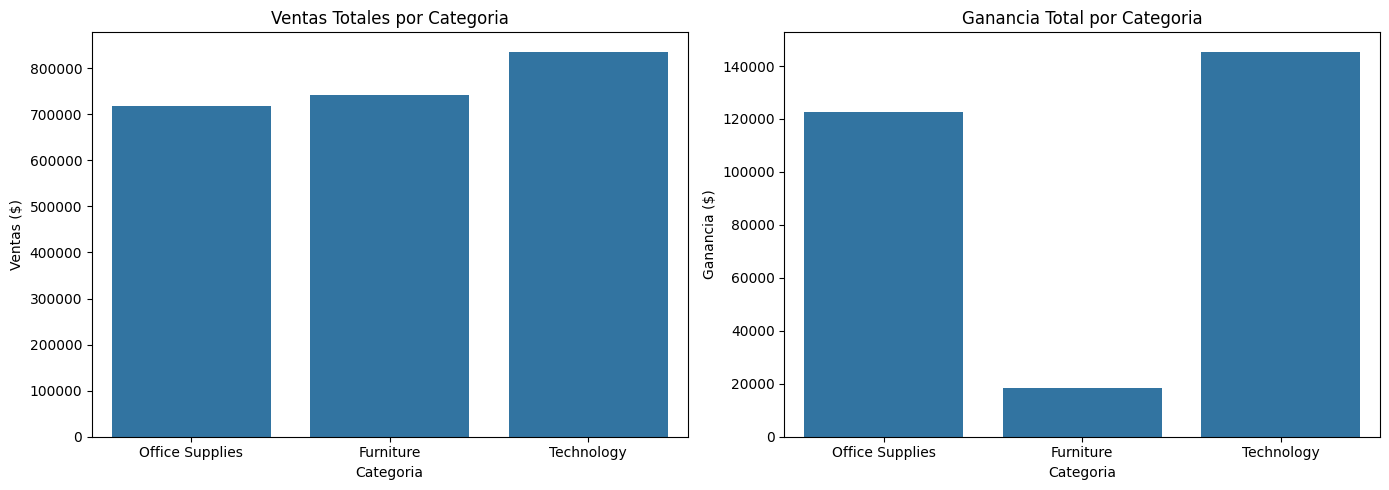

In [10]:
# Se comparan ventas y ganancias por categoría para identificar
# cuál es realmente la más rentable para el negocio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Category', y='Sales', estimator='sum', errorbar=None, ax=axes[0])
axes[0].set_title('Ventas Totales por Categoria')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Ventas ($)')

sns.barplot(data=df, x='Category', y='Profit', estimator='sum', errorbar=None, ax=axes[1])
axes[1].set_title('Ganancia Total por Categoria')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Ganancia ($)')

plt.tight_layout()
plt.show()

## 2. ¿Cómo han evolucionado las ventas a lo largo del tiempo?

Las ventas muestran una **tendencia creciente clara** de 2014 a 2017, 
lo que indica que el negocio está en expansión.

Se observa una **estacionalidad repetida cada año** con dos patrones claros:
- **Picos:** en marzo, septiembre y noviembre/diciembre coincidiendo 
  con temporadas de compras y cierres de trimestre corporativos.
- **Caídas:** a inicio de año (enero/febrero) cuando el consumo 
  se reduce tras las fiestas navideñas.

El **mejor mes registrado fue noviembre 2017** con ~$120K en ventas, 
casi el doble que el promedio mensual de 2014.

**Conclusión:** La estacionalidad es predecible y puede usarse para 
planificar inventario y campañas de marketing en los meses de mayor demanda.

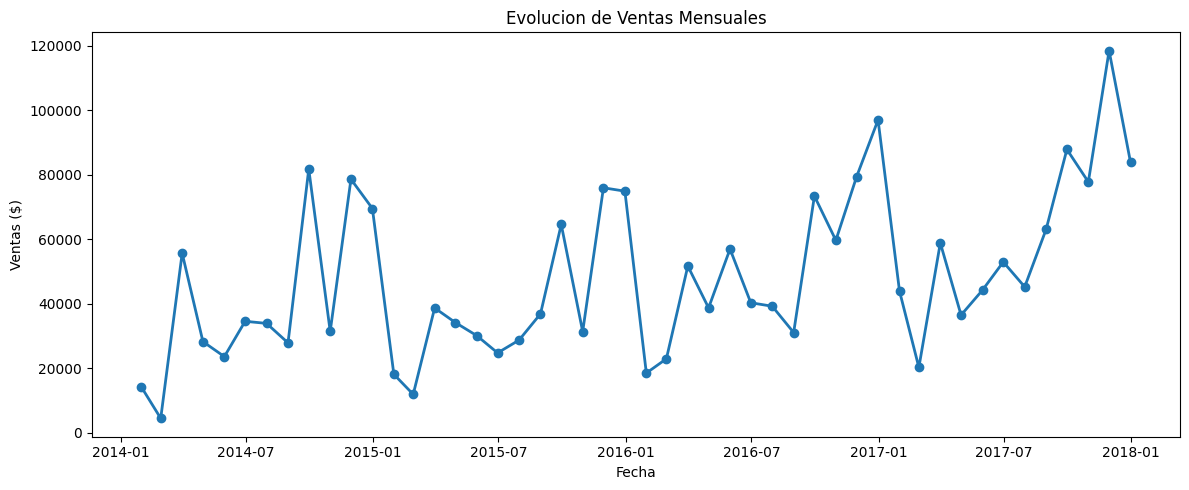

In [ ]:
# Se agrupan las ventas por mes para visualizar la evolución
# temporal e identificar patrones de estacionalidad
df_monthly = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(df_monthly['Order Date'], df_monthly['Sales'], marker='o', linewidth=2)
plt.title('Evolucion de Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas ($)')
plt.tight_layout()
plt.show()


## 3. ¿Qué regiones son las más rentables?

**West** es la región más rentable con ~$108K en ganancia y ~$725K 
en ventas, consolidándose como el mercado más fuerte del negocio.

**East** tiene ventas altas (~$680K) y una ganancia sólida (~$91K), 
siendo la segunda región más importante.

**Central** es la región más preocupante — tiene ventas considerables 
(~$500K) pero una ganancia muy baja (~$40K). Esto sugiere que se están 
aplicando descuentos excesivos o que el mix de productos vendidos 
en esta región tiene márgenes bajos.

**South** es la región más débil tanto en ventas (~$390K) como en 
ganancia (~$46K), representando una oportunidad de crecimiento.

**Conclusión:** West y East son los mercados clave a mantener y potenciar. 
Central requiere una revisión urgente de su política de descuentos 
para mejorar su rentabilidad.

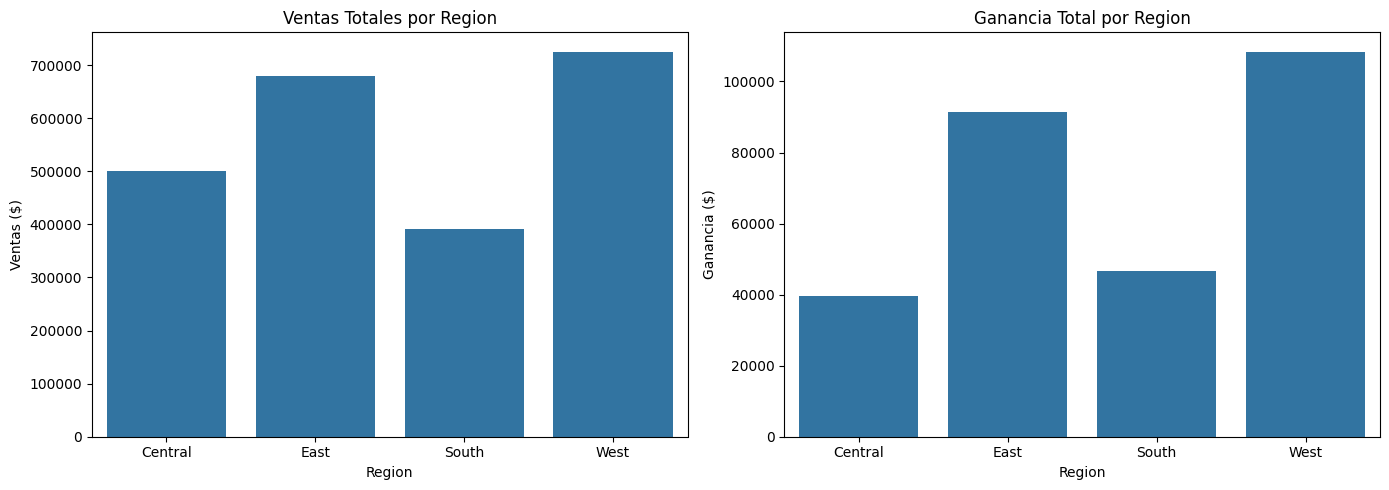

In [ ]:
# Se comparan ventas y ganancias por región para identificar
# cuáles aportan más valor al negocio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Region', y='Sales', estimator='sum', errorbar=None, ax=axes[0])
axes[0].set_title('Ventas Totales por Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Ventas ($)')

sns.barplot(data=df, x='Region', y='Profit', estimator='sum', errorbar=None, ax=axes[1])
axes[1].set_title('Ganancia Total por Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Ganancia ($)')

plt.tight_layout()
plt.show()

## 4. ¿Cómo afectan los descuentos a la ganancia?

El gráfico muestra una **correlación negativa clara** entre el nivel 
de descuento aplicado y la ganancia generada.

Se identifican tres zonas clave:
- **Descuento 0% - 20%:** La mayoría de transacciones son rentables 
  con ganancias que pueden superar los $8,000 por orden.
- **Descuento 30% - 40%:** Las ganancias caen drásticamente y muchas 
  órdenes empiezan a cruzar la línea de pérdidas.
- **Descuento 50% - 80%:** Casi todas las transacciones generan pérdidas, 
  llegando hasta -$6,500 por orden en casos extremos.

El problema es especialmente grave en **Furniture y Office Supplies**, 
donde se concentran los descuentos más altos, explicando su baja 
rentabilidad vista en la pregunta 1.

**Conclusión:** Los descuentos superiores al 20% son destructivos para 
el negocio. Se recomienda establecer un límite máximo del 20% de 
descuento para proteger los márgenes de ganancia.

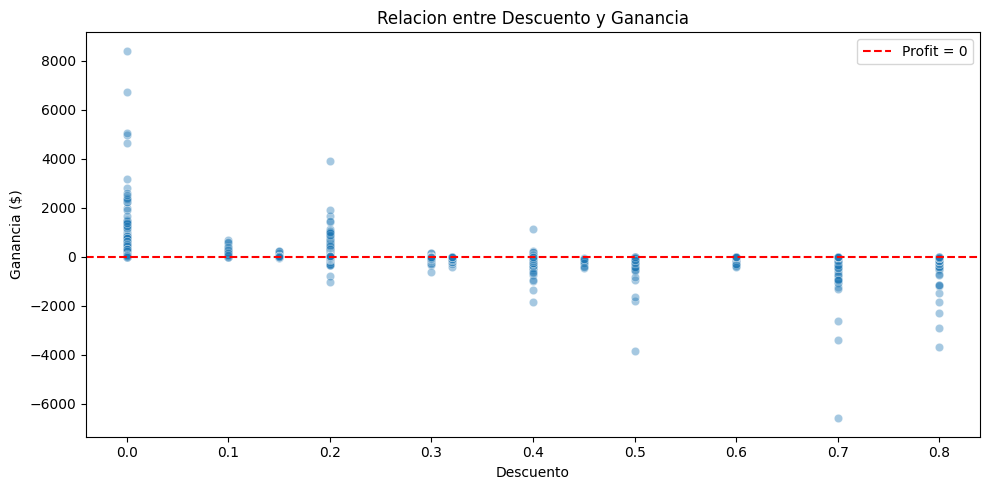

In [ ]:
# Se visualiza la relación entre descuento y ganancia para identificar
# el umbral a partir del cual los descuentos generan pérdidas
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4)
plt.axhline(y=0, color='red', linestyle='--', label='Profit = 0')
plt.title('Relacion entre Descuento y Ganancia')
plt.xlabel('Descuento')
plt.ylabel('Ganancia ($)')
plt.legend()
plt.tight_layout()
plt.show()


## 5. ¿Qué segmento de clientes es el más valioso?

**Consumer** es el segmento dominante con ~$1.16M en ventas y ~$134K 
en ganancia, representando más del 50% del negocio total.

**Corporate** es el segundo segmento más importante con ~$706K en ventas 
y ~$92K en ganancia. Aunque tiene menos volumen que Consumer, su 
ratio ventas/ganancia es más eficiente, lo que indica que los clientes 
corporativos compran con menos descuentos y productos de mayor margen.

**Home Office** es el segmento más pequeño con ~$430K en ventas y 
~$60K en ganancia. Sin embargo, tiene un comportamiento de compra 
similar a Corporate, con márgenes relativamente sanos.

**Conclusión:** Consumer genera el mayor volumen pero Corporate es 
el segmento más eficiente. Una estrategia inteligente sería potenciar 
las ventas corporativas ya que generan más ganancia por dólar vendido 
que el segmento Consumer.


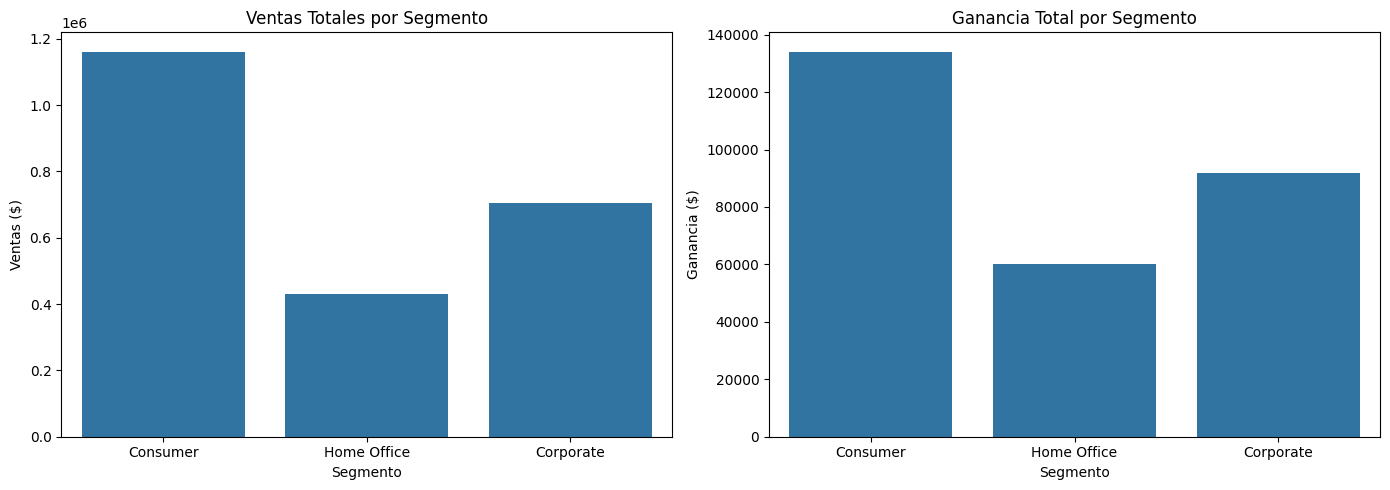

In [ ]:
# Se comparan los segmentos de clientes para identificar
# cuál genera más valor real al negocio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Segment', y='Sales', estimator='sum', errorbar=None, ax=axes[0])
axes[0].set_title('Ventas Totales por Segmento')
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Ventas ($)')

sns.barplot(data=df, x='Segment', y='Profit', estimator='sum', errorbar=None, ax=axes[1])
axes[1].set_title('Ganancia Total por Segmento')
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Ganancia ($)')

plt.tight_layout()
plt.show()


## Conclusiones

**1. Technology es la única categoría verdaderamente rentable** — 
lidera en ventas y ganancia. Furniture vende mucho pero gana poco 
debido a su política de descuentos agresiva, lo que la convierte 
en una categoría de riesgo para el negocio.

**2. El negocio crece pero de forma estacional** — las ventas aumentan 
año a año pero con caídas predecibles a inicio de año. Anticipar 
estos ciclos permite planificar mejor el inventario y las campañas 
de marketing para los meses de mayor demanda.

**3. Los descuentos superiores al 20% destruyen rentabilidad** — 
existe evidencia clara de que a partir del 30% de descuento la mayoría 
de órdenes generan pérdidas. Regions como Central sufren especialmente 
este problema, teniendo ventas altas pero ganancias muy bajas.